In [33]:
import pandas as pd
import numpy as np
import re

secop_df = pd.read_parquet('secop_bienes.parquet')
print('Filas:', secop_df.shape[0])
print('Columnas:', secop_df.shape[1])

Filas: 196391
Columnas: 36


In [34]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
secop_df.columns

Index(['id_contrato', 'nombre_entidad', 'departamento', 'ciudad', 'orden',
       'sector', 'rama', 'entidad_centralizada', 'tipo_de_contrato',
       'modalidad_de_contratacion', 'codigo_de_categoria_principal',
       'objeto_del_contrato', 'fecha_de_firma', 'fecha_de_inicio_del_contrato',
       'fecha_de_fin_del_contrato', 'duraci_n_del_contrato',
       'condiciones_de_entrega', 'proveedor_adjudicado', 'documento_proveedor',
       'es_pyme', 'es_grupo', 'g_nero_representante_legal',
       'nacionalidad_representante_legal', 'valor_del_contrato',
       'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago',
       'dias_adicionados', 'habilita_pago_adelantado',
       'el_contrato_puede_ser_prorrogado', 'origen_de_los_recursos',
       'destino_gasto', 'estado_contrato', 'liquidaci_n',
       'obligaci_n_ambiental', 'urlproceso'],
      dtype='str')

In [35]:
secop_df.dtypes

id_contrato                                    str
nombre_entidad                                 str
departamento                                   str
ciudad                                         str
orden                                          str
sector                                         str
rama                                           str
entidad_centralizada                           str
tipo_de_contrato                               str
modalidad_de_contratacion                      str
codigo_de_categoria_principal                  str
objeto_del_contrato                            str
fecha_de_firma                      datetime64[us]
fecha_de_inicio_del_contrato        datetime64[us]
fecha_de_fin_del_contrato           datetime64[us]
duraci_n_del_contrato                          str
condiciones_de_entrega                         str
proveedor_adjudicado                           str
documento_proveedor                            str
es_pyme                        

In [36]:
def fragmento_sospechoso(variable_temporal_columna):
    fragmentos = variable_temporal_columna.split('_')
    return any(len(frag) == 1 for frag in fragmentos)

columnas_sospechosas = [col for col in secop_df.columns if fragmento_sospechoso(col)]

print("Columnas con posible problema de encoding:")
for col in columnas_sospechosas:
    print(col)

Columnas con posible problema de encoding:
duraci_n_del_contrato
g_nero_representante_legal
liquidaci_n
obligaci_n_ambiental


In [37]:
secop_df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL AMAZONIA,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de precios unitarios; sin formula de reajuste el suministro de elementos de aseo y limpieza e insumos de cafetería y restaurante; para los Parques Nacionales Naturales de Amacayacu; Cahuinarí; Río Puré y Yaigojé Apaporis,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.0,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.846428&isFromPublicArea=True&isModal=true&asPopupView=true'}
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDORES DE TROPA DE LA BR-4 Y BR-14; ADMINISTRADOS POR LA AGENCIA LOGÍSTICA DE LAS FUERZAS MILITARES REGIONAL ANTIOQUIA CHOCO Y OTRAS POSIBLES UNIDADES QUE LO REQUIERAN,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.0,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.841446&isFromPublicArea=True&isModal=true&asPopupView=true'}
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CANUTILLO PARA OFICIALES DE INSIGNIA DE LA FUERZA AÉREA COLOMBIANA CONFORME ANEXO TECNICO,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino convenido),FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.0,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.846657&isFromPublicArea=True&isModal=true&asPopupView=true'}
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,V1.41115300,ADQUISICIÓN DE UN SISTEMA DE SONAR 3D DE ALTA RESOLUCIÓN CON DESTINO AL DEPARTAMENTO DE BUCEO Y SALVAMENTO,2019-07-25,2019-07-12,2019-11-30,Dia(s),Como acordado previamente,CASCO ANTIGUO,76044753,No,No,Otro,CO,733992000.0,0,0,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.826239&isFromPublicArea=True&isModal=true&asPopupView=true'}
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.92121701,Suministro de equipos para la instalación de todas las cámaras necesarias para el monitoreo; para ser instalados en\nlas sedes oper

In [38]:
secop_df.tail

<bound method NDFrame.tail of                id_contrato  \
0       CO1.PCCNTR.1000001   
1       CO1.PCCNTR.1000507   
2       CO1.PCCNTR.1000901   
3       CO1.PCCNTR.1000908   
4       CO1.PCCNTR.1000911   
...                    ...   
196386   CO1.PCCNTR.999805   
196387   CO1.PCCNTR.999806   
196388   CO1.PCCNTR.999807   
196389   CO1.PCCNTR.999810   
196390   CO1.PCCNTR.999902   

                                                                    nombre_entidad  \
0       PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION  TERRITORIAL AMAZONIA   
1                                       AGENCIA LOGISTICA DE LAS FUERZAS MILITARES   
2                                                   FUERZA AEROESPACIAL COLOMBIANA   
3                                       AGENCIA LOGISTICA DE LAS FUERZAS MILITARES   
4          PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE   
...                                                                            ...   
196386 

In [39]:
# 1. ¿Cuántos IDs únicos hay vs. cuántas filas totales?
print("Total de filas:", len(secop_df))
print("IDs únicos:", secop_df['id_contrato'].nunique())

# 2. Si los números no coinciden, hay duplicados
duplicados = secop_df['id_contrato'].duplicated().sum()
print("Filas con id_contrato repetido:", duplicados)

Total de filas: 196391
IDs únicos: 196391
Filas con id_contrato repetido: 0


In [40]:
secop_df.sample(10)

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
98777,CO1.PCCNTR.5298908,COMANDO GENERAL DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.42192209,CONTRATAR LA ADQUISICIÓN E INSTALACIÓN DE RAMPAS PARA PERSONAS CON DISCAPACIDAD FÍSICA (MUSEO CANDELARIA); DE ACUERDO CON LAS ESPECIFICACIONES TÉCNICAS DEL ANEXO,2023-08-23,2023-08-30,2023-11-30,106 Dia(s),No Definido,CONSTRUEQUIPOS BOGOTA S.A.S,901079794,Si,No,Hombre,CO,13400000.0,13400000,13400000,0,0,No,No,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.4782649&isFromPublicArea=True&isModal=true&asPopupView=true'}
25356,CO1.PCCNTR.2007994,SENA REGIONAL BOYACA Grupo Administrativo CDAA,Boyacá,Duitama,Nacional,Trabajo,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.70171700,CONTRATAR LA COMPRA DE MATERIALES DIRIGIDOS A LA FORMACIÓN QUE ADELANTAN LOS PROGRAMAS DE ARTICULACIÓN CON LA EDUCACIÓN MEDIA DOBLE TITULACIÓN Y ATENCIÓN A POBLACIÓN VÍCTIMA DEL CENTRO DE DESARROLLO AGROPECUARIO Y AGROINDUSTRIAL DEL SENA OTROS BIENES TRANSPORTABLES EXCEPTO PRODUCTOS METÁLICOS MAQUINARIA Y EQUIPO,2020-11-24,2020-12-22,2021-04-16,1 Mes(es),Como acordado previamente,SERVICIOS AGROPECUARIOS Y AMBIENTALES S.A.S,900541728,Si,No,No Definido,CO,58387355.0,58387355,58387355,0,0,No Definido,Si,Distribuido,Inversión,terminado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.1549397&isFromPublicArea=True&isModal=true&asPopupView=true'}
180082,CO1.PCCNTR.8508246,IE SAGRADOS CORAZONES FLORENCIA,No Definido,No Definido,Territorial,Educación Nacional,Ejecutivo,Centralizada,Suministros,Contratación régimen especial,V1.14111807,SUMINISTRO KIT ELECTRONICA PARA MODALIDAD INFORMATICA,2025-10-28,2025-10-29,2025-11-21,20 Dia(s),NXTWY.DLVY.2,Club de Estudios Electronicos San Pio de Pietrelcina,17688672,No,No,Hombre,CO,3065000.0,0,0,3065000,0,No,No,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.9019784&isFromPublicArea=True&isModal=true&asPopupView=true'}
118354,CO1.PCCNTR.6091601,MUNICIPIO DE ABEJORRAL,Antioquia,Abejorral,Territorial,Servicio Público,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.78111800,PRESTACIÓN DE SERVICIOS DE TRANSPORTE PARA LA ATENCIÓN\nDESCENTRALIZADA A LA POBLACIÓN DEL ÁREA RURAL QUE\nREQUIERA DE LOS SERVICIOS OFRECIDOS POR LA SECRETARIA DE\nSALUD; PROTECCION Y BIENESTAR SOCIAL Y DEPENDENDENCIAS\nDE LA ALCALDIA; BAJO LA MODALIDAD JORNADAS\nINTERINSTITUCIONALES COMUNITARIAS,2024-04-05,2024-04-05,2024-12-31,289 Dia(s),No Definido,COOPERATIVA DE TRANSPORTES DE ABEJORRAL,811016454,Si,No,Hombre,CO,4490000.0,0,0,4490000,0,No,No,Distribuido,Funcionamiento,En ejecución,No,No,{'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.5818216&isFromPublicArea=True&isModal=true&asPopupView=true'}
137444,CO1.PCCNTR.6857767,ALCALDIA MUNICIPAL DE VILLETA,Cundinamarca,Villeta,Territorial,Servicio Público,Ejecutivo,Centralizada,Suministros,Selección abreviada subasta inversa,V1.14111700,CONTRATAR EL SUMINISTRO DE PRODUCTOS DE MERCADO DE PLAZA; MERCADO DE TIENDA; CARNICOS; ASEO E INSUMOS DE ENFERMERIA Y FARMACIA PARA EL FUNCIONAMIENTO DEL CENTR

In [41]:
secop_df.describe()

,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados
count,196391,193951,196391,1.963910e+05,1.963910e+05,1.963910e+05,1.963910e+05,196391.000000
mean,2023-02-27 22:45:53.539622,2023-03-01 13:02:29.326376,2023-06-11 04:37:50.596921,6.582426e+10,1.194911e+08,1.484092e+08,6.570476e+10,5.107485
min,2019-01-01 00:00:00,2016-06-27 00:00:00,0202-12-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,-8.418488e+07,0.000000
25%,2021-09-10 00:00:00,2021-09-17 00:00:00,2021-12-20 00:00:00,1.202121e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,2023-05-30 00:00:00,2023-06-05 00:00:00,2023-10-27 00:00:00,3.360000e+07,0.000000e+00,3.207328e+06,6.717571e+06,0.000000
75%,2024-11-07 00:00:00,2024-11-14 00:00:00,2024-12-31 00:00:00,1.000000e+08,2.812077e+07,3.708622e+07,4.241189e+07,0.000000
max,2025-12-31 00:00:00,2026-12-16 00:00:00,2065-01-31 00:00:00,1.285845e+16,5.944034e+11,5.945032e+11,1.285845e+16,14276.000000
std,NaN,NaN,NaN,2.901535e+13,2.444116e+09,2.969810e+09,2.901535e+13,40.662426


In [42]:
secop_df['sector'].nunique()

26

In [43]:
secop_df['sector'].value_counts()

sector
Servicio Público                                      37390
defensa                                               34585
No aplica/No pertenece                                24465
Salud y Protección Social                             22037
Ley de Justicia                                       20377
Trabajo                                               14759
Educación Nacional                                    10231
Ambiente y Desarrollo Sostenible                       8109
Transporte                                             4655
Cultura                                                2792
deportes                                               2610
Hacienda y Crédito Público                             2441
Industria                                              1807
Vivienda, Ciudad y Territorio                          1497
Planeación                                             1319
agricultura                                            1254
interior                         

In [44]:
secop_df['tipo_de_contrato'].nunique()

2

In [45]:
secop_df['tipo_de_contrato'].value_counts()

tipo_de_contrato
Suministros    106632
Compraventa     89759
Name: count, dtype: int64

In [46]:
secop_df['fecha_de_firma'].dt.year.value_counts().sort_index()

fecha_de_firma
2019    16425
2020    20135
2021    24043
2022    28070
2023    32971
2024    34634
2025    40113
Name: count, dtype: int64

<Axes: >

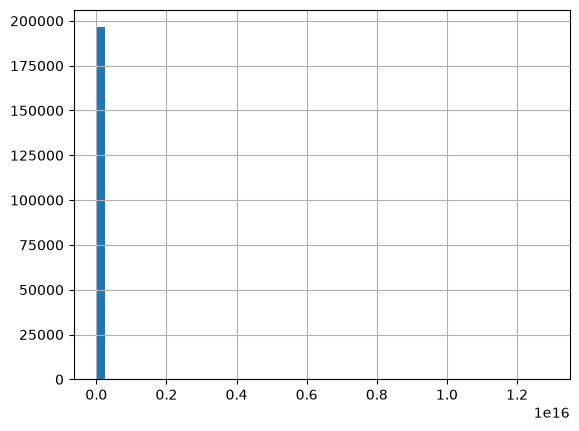

In [47]:
secop_df['valor_del_contrato'].hist(bins=50)

In [48]:
secop_df['valor_del_contrato'].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

0.01    7.010680e+05
0.25    1.202121e+07
0.50    3.360000e+07
0.75    1.000000e+08
0.99    4.118482e+09
Name: valor_del_contrato, dtype: float64

## Hallazgos
- Nombres de columna con ploblemas de encoding (duraci_n_del_contrato, g_nero_representante_legal, liquidaci_n, obligaci_n_ambiental)
- La granularidad es una fila un id_contrato unico.